siema

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, value, LpStatus


In [45]:
# 1. Wczytanie danych z pliku CSV
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
criteria = ['C1', 'C2', 'C3', 'C4']

In [46]:
# 2. Definicja par referencyjnych (zgodnie z naszą analizą)
# Format: (lepszy_wariant, gorszy_wariant)
preferences = [
    (22, 3),   # Para 10: 22 > 3
    (8, 7),    # Para 36: 8 > 7
    (21, 10),  # Para 1: 21 > 10
    (14, 25),  # Para 5: 14 > 25
    (13, 18),   # Para 13: 13 > 18
    (17, 12)    # eksperymentalnie: 17 > 12
]

In [47]:
# Pobranie unikalnych, posortowanych wartości dla każdego kryterium
# Będą one stanowić punkty załamania (tzw. breakpoints) naszej funkcji
values = {}
for c in criteria:
    values[c] = np.sort(df[c].unique())

In [48]:
# 3. Inicjalizacja modelu programowania liniowego - metoda UTA (Maksymalizacja)
model = LpProblem("UTA_Max_Epsilon", LpMaximize)

In [49]:
# Zmienna epsilon, którą chcemy zmaksymalizować
epsilon = LpVariable("epsilon", lowBound=0)

In [50]:
# 4. Utworzenie zmiennych decyzyjnych (użyteczności cząstkowych)
# U_vars[kryterium][wartość] = zmienna Pulp
U_vars = {}
for c in criteria:
    U_vars[c] = {}
    for val in values[c]:
        # Wartości użyteczności cząstkowych nie mogą być ujemne
        var_name = f"U_{c}_{val}".replace(".", "_")
        U_vars[c][val] = LpVariable(var_name, lowBound=0)

In [51]:
# 5. Ograniczenia dla metody UTA
# a) Monotoniczność: wyższa ocena w znormalizowanym CSV (bliżej 1.0) = większa użyteczność
for c in criteria:
    vals = values[c]
    for i in range(len(vals) - 1):
        model += U_vars[c][vals[i]] <= U_vars[c][vals[i+1]], f"Monotonicity_{c}_{i}"

# b) Użyteczność dla najgorszej możliwej oceny w danym kryterium musi wynosić 0
for c in criteria:
    min_val = values[c][0]
    model += U_vars[c][min_val] == 0, f"Min_Utility_0_{c}"

In [52]:
# c) Ograniczenia na wagi (suma maksymalnych użyteczności cząstkowych = 1)
max_utilities = []
for c in criteria:
    max_val = values[c][-1]
    max_utilities.append(U_vars[c][max_val])
    # Zgodnie z wytycznymi, waga każdego kryterium to min. 0.1
    model += U_vars[c][max_val] >= 0.1, f"Min_Weight_{c}"

model += lpSum(max_utilities) == 1.0, "Sum_of_Weights_1"

In [53]:
# 6. Dodanie ograniczeń dla ocenionych par referencyjnych
# Funkcja pomocnicza obliczająca globalną użyteczność dla wariantu
def get_global_utility(variant_id):
    row = df.loc[variant_id]
    return lpSum([U_vars[c][row[c]] for c in criteria])

for idx, (better, worse) in enumerate(preferences):
    U_better = get_global_utility(better)
    U_worse = get_global_utility(worse)
    # Globalna użyteczność lepszego wariantu >= gorszego + epsilon
    model += U_better >= U_worse + epsilon, f"Preference_{better}_better_than_{worse}"

In [54]:
# 7. Funkcja celu: Maksymalizacja zmiennej epsilon
model += epsilon, "Objective_Function"

In [55]:
# 8. Uruchomienie solvera
model.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/maciek/projects/IMWD/IWD/.venv/lib/python3.13/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/89/sgmkb2l176d2d5401rmh7t5r0000gn/T/2004cbbce38c4f58be42b9e4901fbcd0-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/89/sgmkb2l176d2d5401rmh7t5r0000gn/T/2004cbbce38c4f58be42b9e4901fbcd0-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 93 COLUMNS
At line 307 RHS
At line 396 BOUNDS
At line 397 ENDATA
Problem MODEL has 88 rows, 78 columns and 212 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 14 (-74) rows, 12 (-66) columns and 53 (-159) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 0.00086814203 ( 0.086814203%) - largest zero change 0.00043177856
0  Obj -0.00014139029 Primal inf 0.799998 (2) Dual inf 0.99913086 (1)
13  Obj 0.19925041
Optim

1

Status modelu: Optimal
Zoptymalizowana wartość funkcji celu (epsilon) = 0.2000

--- RANKING WSZYSTKICH WARIANTÓW ---
         Wariant  Uzytecznosc
Pozycja                      
1             14          0.9
2             13          0.9
3              4          0.8
4              1          0.8
5             25          0.7
6             27          0.7
7             26          0.7
8              8          0.7
9              9          0.7
10            24          0.7
11            23          0.7
12            21          0.7
13            15          0.7
14            20          0.7
15            17          0.7
16            18          0.7
17            19          0.6
18            22          0.6
19            16          0.6
20             2          0.6
21            11          0.5
22            10          0.5
23             7          0.5
24             6          0.4
25             3          0.4
26            12          0.4
27             5          0.4


--- WAGI KR

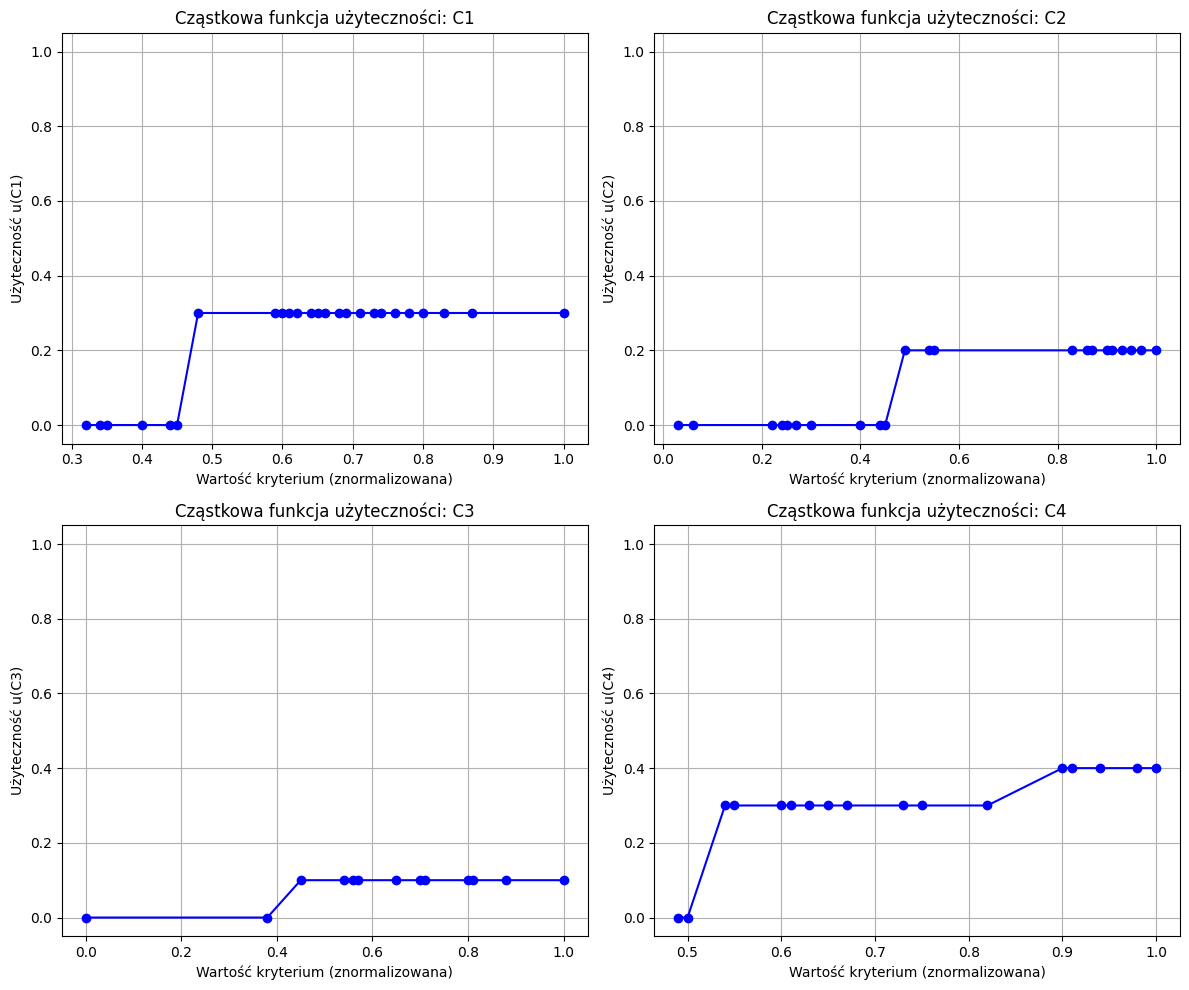

In [56]:
# 9. Analiza wyników
print(f"Status modelu: {LpStatus[model.status]}")
if LpStatus[model.status] == "Optimal":
    print(f"Zoptymalizowana wartość funkcji celu (epsilon) = {value(epsilon):.4f}\n")
    
    # Obliczanie użyteczności globalnych dla wszystkich wariantów
    results = []
    for variant in df.index:
        global_u = sum([value(U_vars[c][df.loc[variant, c]]) for c in criteria])
        results.append({"Wariant": variant, "Uzytecznosc": global_u})
    
    # Tworzenie rankingu
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="Uzytecznosc", ascending=False).reset_index(drop=True)
    results_df.index += 1  # Numeracja od 1 (miejsce w rankingu)
    results_df.index.name = "Pozycja"
    
    print("--- RANKING WSZYSTKICH WARIANTÓW ---")
    print(results_df.to_string())
    print("\n")
    
    print("--- WAGI KRYTERIÓW (Max użyteczność) ---")
    for c in criteria:
        max_val = values[c][-1]
        print(f"Waga kryterium {c}: {value(U_vars[c][max_val]):.4f}")

    # 10. Rysowanie wykresów cząstkowych funkcji użyteczności
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, c in enumerate(criteria):
        x_vals = values[c]
        y_vals = [value(U_vars[c][x]) for x in x_vals]
        
        axes[i].plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
        axes[i].set_title(f"Cząstkowa funkcja użyteczności: {c}")
        axes[i].set_xlabel("Wartość kryterium (znormalizowana)")
        axes[i].set_ylabel(f"Użyteczność u({c})")
        axes[i].grid(True)
        # Ustawiamy sztywną oś Y od 0 do 1 dla czytelności
        axes[i].set_ylim([-0.05, 1.05])
        
    plt.tight_layout()
    plt.show()

else:
    print("Solver nie znalazł optymalnego rozwiązania (Status: Infeasible).")
    print("Oznacza to, że założone preferencje są ze sobą sprzeczne dla tych danych.")